# Chromatin PTR analysis
February 32, 2024

Update PTR analysis of latest chromatin deconvolution results. Higher resolution chromatin results. Goal is to summarize a gene's cycling chromatin with a top k values of cycling chromatin.

Possibly sweep for what k values can be reasonable. Maybe think through how we can sweep for an appropriate k.

In [2]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [159]:
import glob

outdir = 'output/deconvolve_rep1_g006_2024_02_20/chromatin/'

from cc_src.peak_to_trough_anaysis import PeakToTroughAnalysis

peak_to_trough_analysis = PeakToTroughAnalysis(outdir)


In [160]:
peak_to_trough_analysis.load_ptr_files()
peak_to_trough_analysis.sort_gene_ptrs()
peak_to_trough_analysis.compute_gene_ptr_rank_per_k()

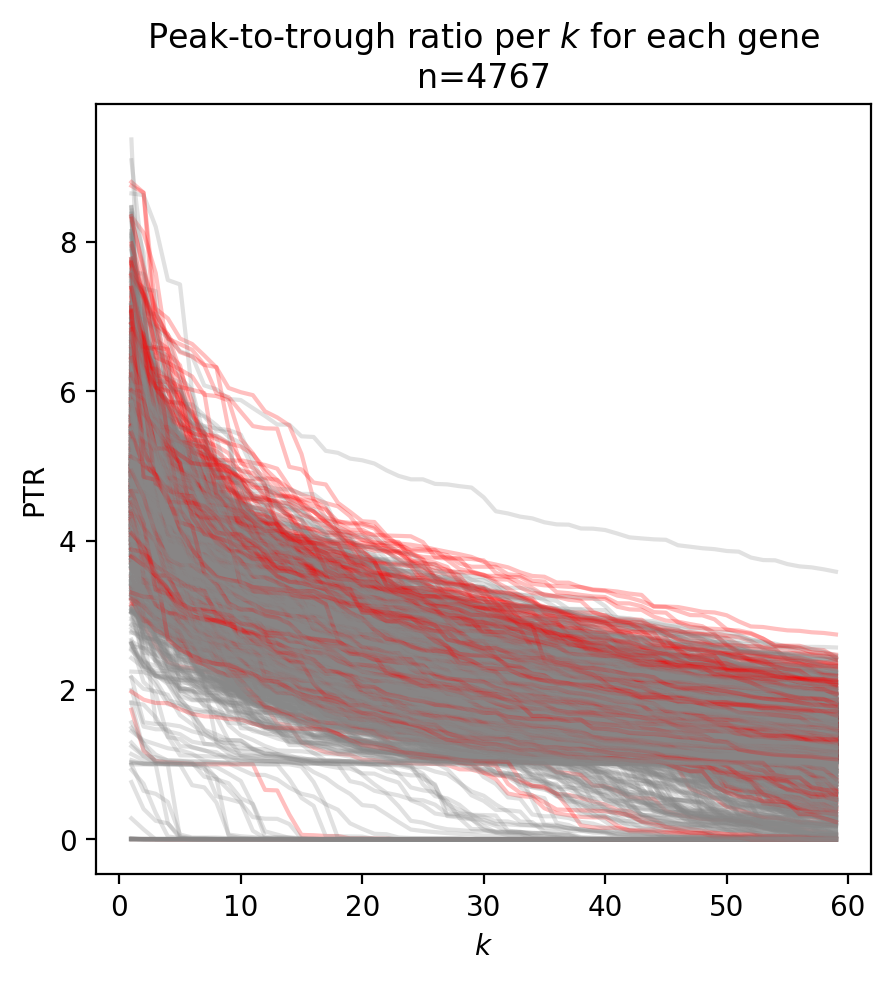

In [161]:
peak_to_trough_analysis.plot_ptr_k_gene()

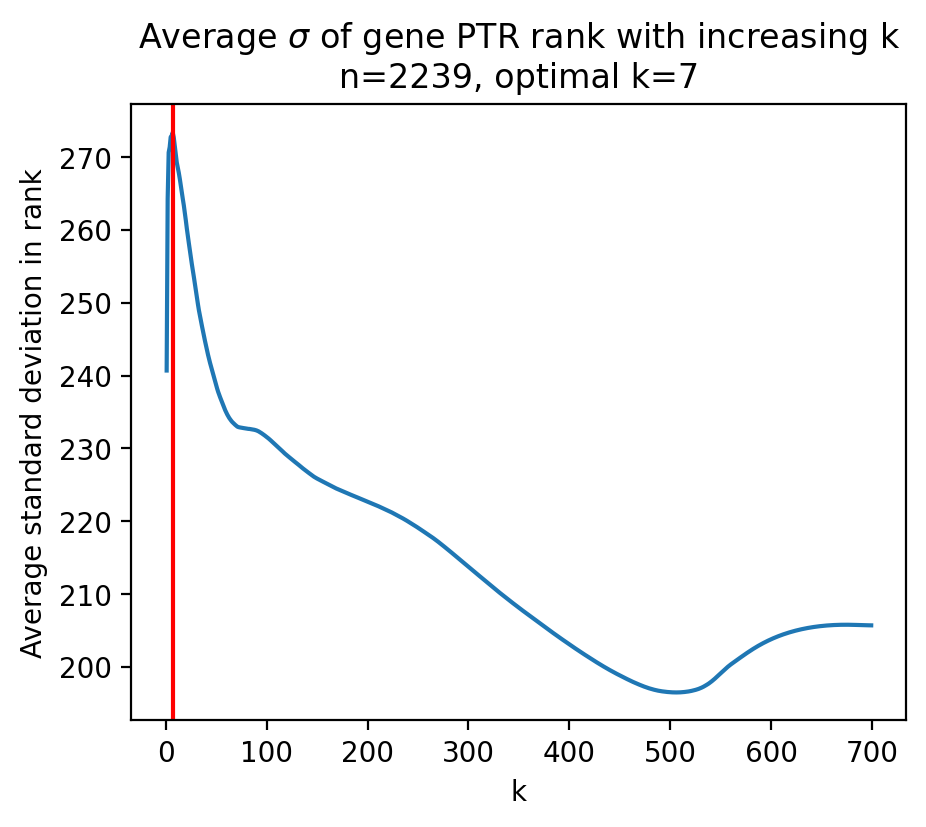

In [148]:
peak_to_trough_analysis.compute_optimal_k()

In [153]:
peak_to_trough_analysis.set_optimal_k(60)

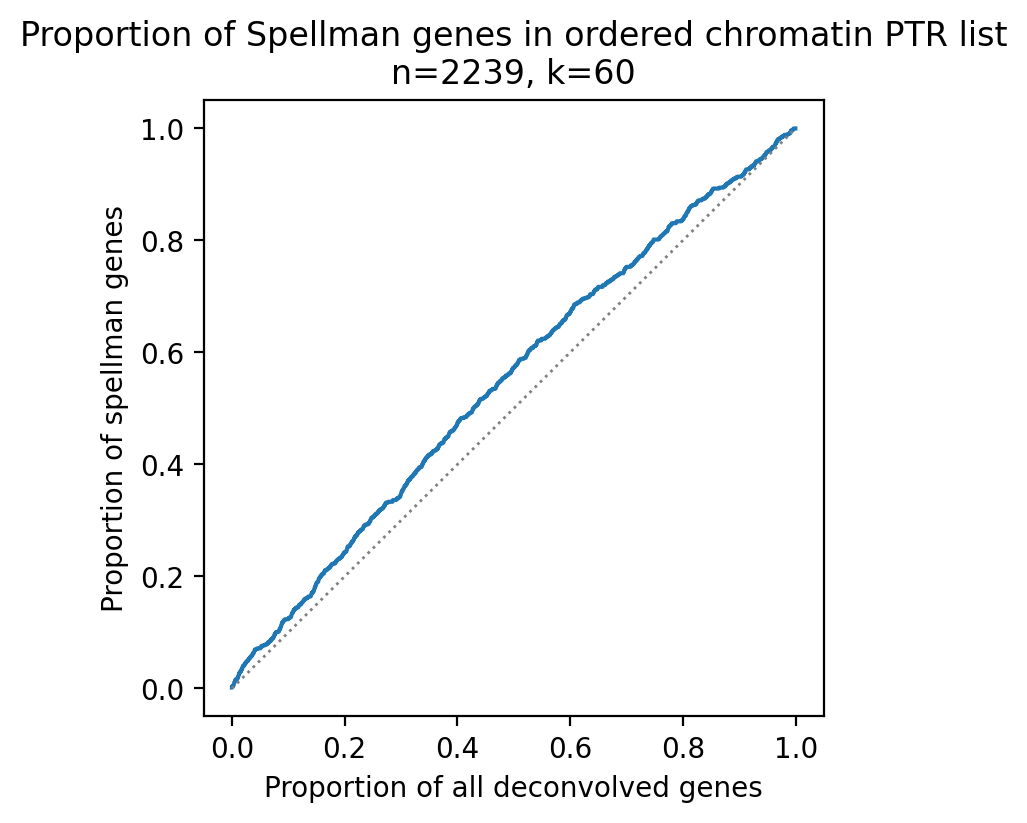

In [154]:
peak_to_trough_analysis.spellman_analysis()

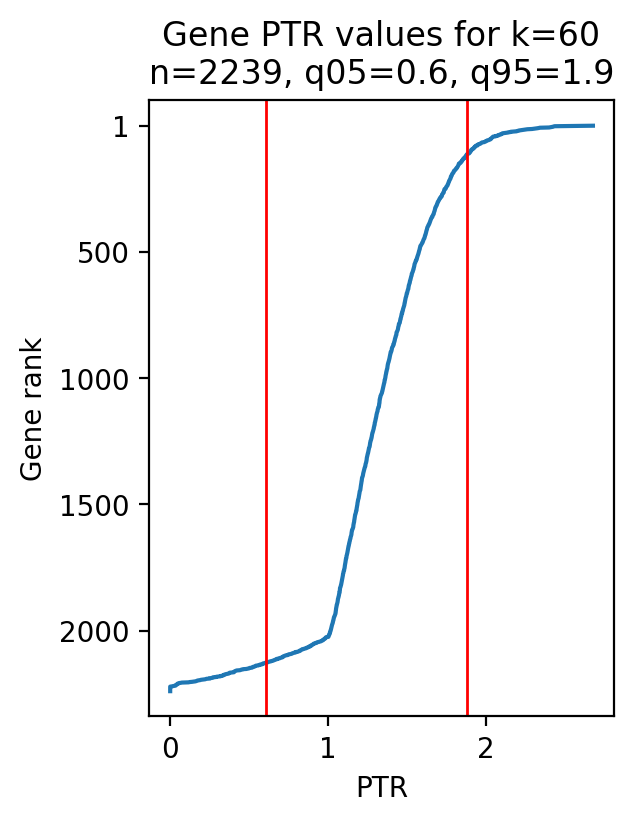

In [155]:
peak_to_trough_analysis.plot_ptrs_per_gene()

In [156]:
peak_to_trough_analysis.k_sorted_genes.head(10)

,rank,gene,ptr,spellman
orf_name,,,,
YPL061W,0,ALD6,2.680842,True
YOL086C,1,ADH1,2.565713,False
YPR159W,2,KRE6,2.438348,True
YNL145W,3,MFA2,2.43166,True
YOR348C,4,PUT4,2.428654,False
YNR024W,5,MPP6,2.419809,False
YLR110C,6,CCW12,2.407429,False
YER145C,7,FTR1,2.403164,True
YBR158W,8,AMN1,2.344013,True


In [157]:
peak_to_trough_analysis.k_sorted_genes[peak_to_trough_analysis.k_sorted_genes.gene == 'CLB2']

,rank,gene,ptr,spellman
orf_name,,,,
YPR119W,756,CLB2,1.464533,True


In [158]:
peak_to_trough_analysis.k_sorted_genes.tail(10)

,rank,gene,ptr,spellman
orf_name,,,,
YOR391C,2229,HSP33,0.000011,False
YLR461W,2230,PAU4,0.000011,False
YKR105C,2231,VBA5,0.00001,False
YFL060C,2232,SNO3,0.00001,True
YPL280W,2233,HSP32,0.00001,False
YNL335W,2234,DDI3,0.00001,False
YLL064C,2235,PAU18,0.00001,False
YLR466W,2236,YRF1-4,0.00001,False
YNL336W,2237,COS1,0.00001,False


## Evaluating different metrics to summarize gene PTR's

Next, we will evaluate other metrics that can capture a larger summary of the PTR image per gene. 

Metrics:
- Mean
- Median
- Quantiles: 80, 20

Evaluation:
- Plot a set of 20 genes and their PTR images, and evaluate how each metric measures up per gene.


In [197]:

ptrs = peak_to_trough_analysis.ptrs_df


def summarize_ptrs(ptrs, metric_func):
    summary_ptrs = ptrs.copy()   
    metric_val = summary_ptrs.apply(metric_func, axis=1)
    return metric_val

q95 = lambda val : np.quantile(val, q=0.95)
q80 = lambda val : np.quantile(val, q=0.8)
q20 = lambda val : np.quantile(val, q=0.2)

mean = summarize_ptrs(ptrs, np.mean)
median = summarize_ptrs(ptrs, np.median)

q95_vals = summarize_ptrs(ptrs, q95)
q80_vals = summarize_ptrs(ptrs, q80)
q20_vals = summarize_ptrs(ptrs, q20)

summary_ptrs = ptrs[[]].copy()

summary_ptrs.loc[:, 'mean'] = mean
summary_ptrs.loc[:, 'median'] = median
summary_ptrs.loc[:, 'q80'] = q80_vals
summary_ptrs.loc[:, 'q20'] = q20_vals
summary_ptrs.loc[:, 'q95'] = q95_vals


In [198]:
summary_ptrs.head()

,mean,median,q80,q20,q95
orf_name,,,,,
YAL068C,0.042479,0.000011,0.000011,0.000011,0.000258
YAL067C,0.352609,0.000013,0.278411,0.000012,2.245895
YAL063C,0.249989,0.000012,0.000026,0.000012,1.808945
YAL062W,0.177905,0.000012,0.000016,0.000012,1.335394
YAL061W,0.242065,0.000012,0.000019,0.000012,1.655772


0

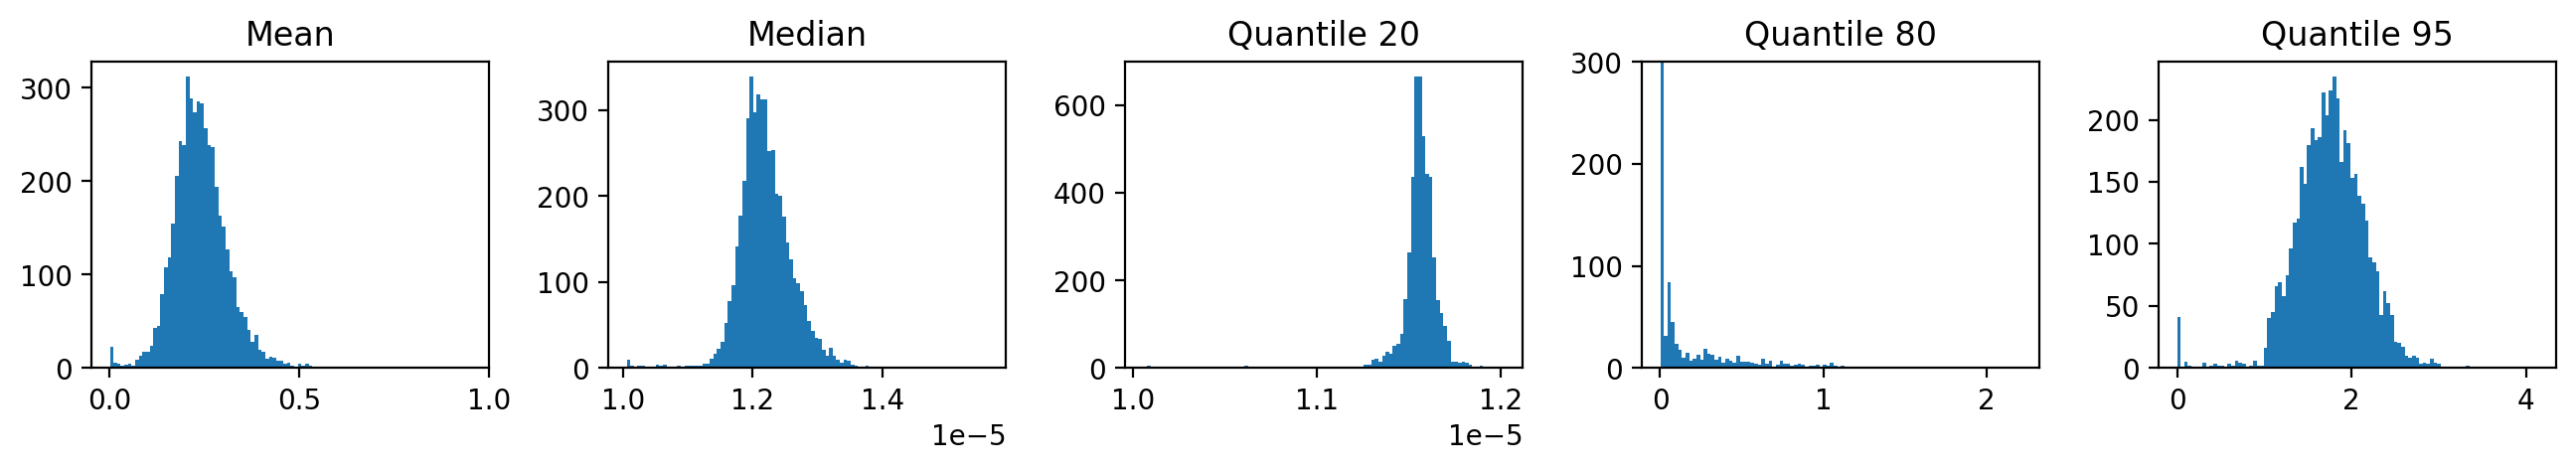

In [220]:
plt.figure(figsize=(16, 2))
plt.subplots_adjust(wspace=0.3)
plt.subplot(1, 5, 1)
plt.hist(summary_ptrs['mean'], bins=100)
plt.title("Mean")
plt.subplot(1, 5, 2)
plt.hist(summary_ptrs['median'], bins=100)
plt.title("Median")
plt.subplot(1, 5, 3)
plt.hist(summary_ptrs['q20'], bins=100)
plt.title("Quantile 20")
plt.subplot(1, 5, 4)
plt.hist(summary_ptrs['q80'], bins=100)
plt.title("Quantile 80")
plt.ylim(0, 300)
plt.subplot(1, 5, 5)
plt.hist(summary_ptrs['q95'], bins=100)
plt.title("Quantile 95")
0

In [235]:

def indices_for_quantiles(series, qs):
    """Get a list of indices for a given list of quantiles"""
    def idxquantile(s, q):
        """Get the index name for the given quantile"""
        qv = s.quantile(q)
        return (s.sort_values()[::-1] <= qv).idxmax()
    return [idxquantile(series, q=q) for q in qs]


In [315]:
# A function to order by the metric, and plot 20 genes equally spaced along the distribution of the metric
def plot_metric_examples_quantiles(summary_ptrs, metric_name):
    vals = summary_ptrs[metric_name]
    qs = np.linspace(1, 0, 20)

    # Now we have ORFs for our quantiles we can compare the images for each
    # of these quantile steps
    quantile_orf_names = indices_for_quantiles(vals, qs)

    n = len(quantile_orf_names)
    fig, axs = plt.subplots(n, 1, figsize=(2, 13))
    plt.subplots_adjust(hspace=0.5)

    for i in range(n):

        orf_name = quantile_orf_names[i]
        quantile_val = qs[i]
        title = f"{quantile_val*100:.0f}%"
        ax = axs[i]

        if i == 0:
            ax.set_title(metric_name)

        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_ylabel(title, rotation=0, ha='right')
        
        strand = peak_to_trough_analysis.geneset.loc[orf_name].strand

        img = ptrs.loc[orf_name].values.reshape(peak_to_trough_analysis.image_shape).astype(float)
        ax.imshow(img, cmap='Blues', vmax=5, origin='lower', aspect='auto',
                 extent=[0, img.shape[1], 0, img.shape[0]])
        
        # todo: hard-coded bin dimensions
        bin_width = 16
        prom_size = 288
        window_size = 800
        
        if strand == '-':
            ax.set_xlim(ax.get_xlim()[1], ax.get_xlim()[0])
            ax.axvline((window_size-prom_size)/bin_width, c='red', alpha=0.25)
        else:
            ax.axvline(prom_size/bin_width, c='red', alpha=0.25)
        

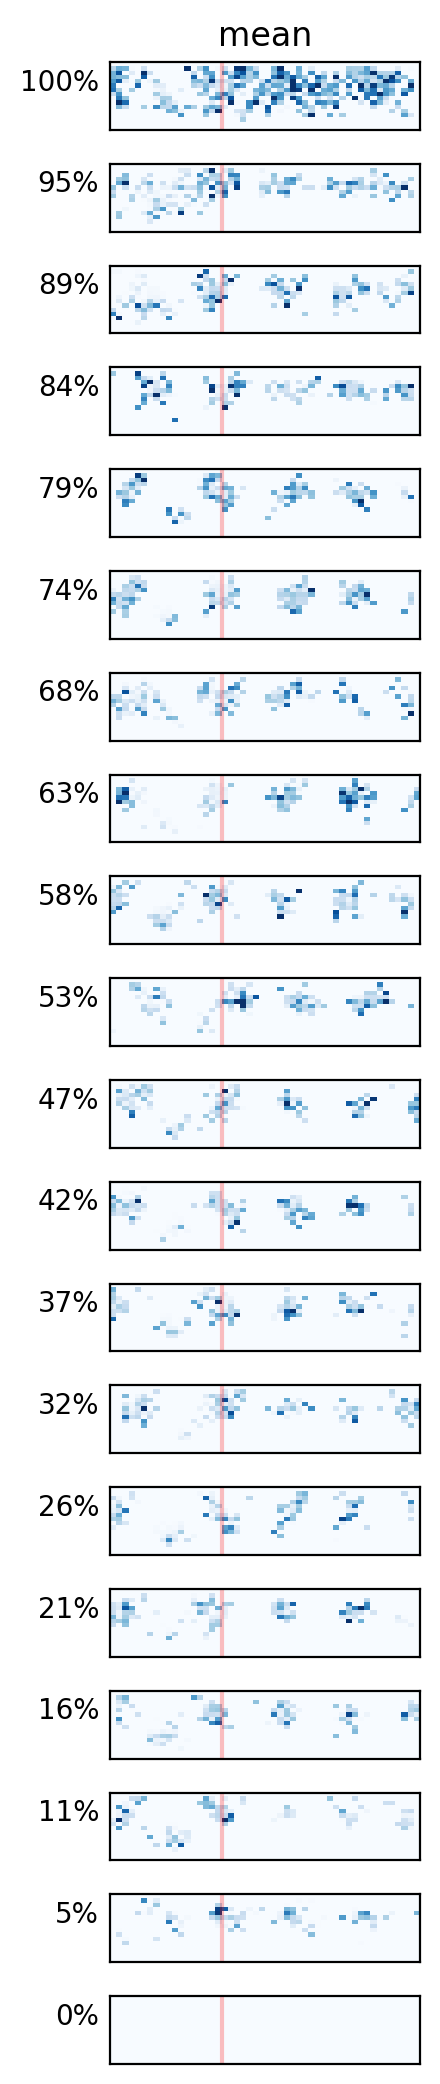

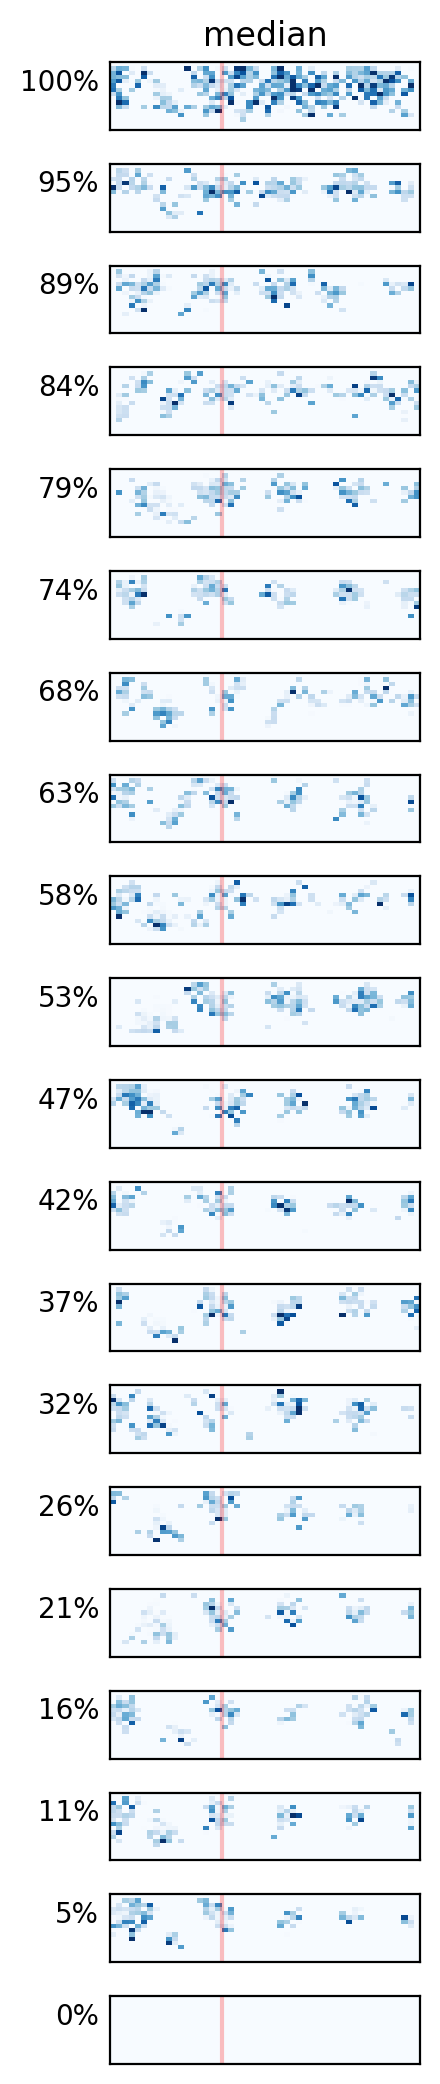

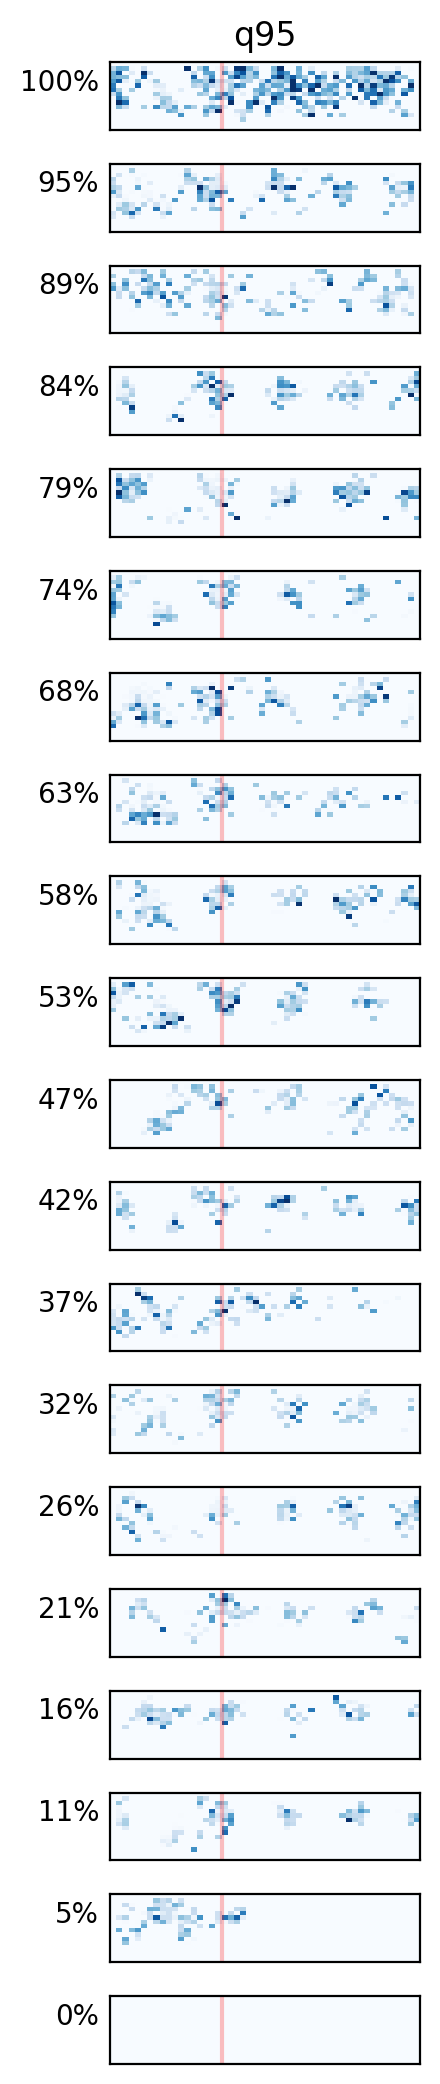

In [316]:
plot_metric_examples_quantiles(summary_ptrs, 'mean')
plot_metric_examples_quantiles(summary_ptrs, 'median')
plot_metric_examples_quantiles(summary_ptrs, 'q95')